# SUMO Road Network Graph Reduction for Drone ACO

Parse the Roxborough SUMO network into a NetworkX graph, visualize it, and explore pruning strategies to reduce the graph for ACO traversal.

In [1]:
import sumolib
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import numpy as np

## 1. Load SUMO Network and Build NetworkX Graph

In [2]:
NET_FILE = "../../../../../../Examples/NFDRS4_Behave/Roxborough/sumo/rox_big.net.xml"

sumo_net = sumolib.net.readNet(NET_FILE)
print(f"SUMO edges: {len(sumo_net.getEdges())}")
print(f"SUMO nodes: {len(sumo_net.getNodes())}")

SUMO edges: 2377
SUMO nodes: 1026


In [3]:
def sumo_to_networkx(sumo_net):
    """Convert SUMO network to an undirected NetworkX graph.
    
    We treat the road network as undirected because drones fly above roads
    and can scan in either direction. Each SUMO edge becomes an undirected
    edge weighted by its length.
    """
    G = nx.Graph()
    
    for node in sumo_net.getNodes():
        coord = node.getCoord()
        G.add_node(node.getID(), x=coord[0], y=coord[1])
    
    for edge in sumo_net.getEdges():
        from_id = edge.getFromNode().getID()
        to_id = edge.getToNode().getID()
        length = edge.getLength()
        edge_type = edge.getType()
        
        # For undirected graph, we store the SUMO edge IDs on each graph edge
        if G.has_edge(from_id, to_id):
            # Edge already exists (reverse direction), just append metadata
            G[from_id][to_id]['sumo_ids'].append(edge.getID())
        else:
            G.add_edge(from_id, to_id,
                       weight=length,
                       edge_type=edge_type,
                       sumo_ids=[edge.getID()])
    
    return G

G = sumo_to_networkx(sumo_net)
print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_connected_components(G)}")

NetworkX graph: 1026 nodes, 1295 edges
Connected components: 7


In [4]:
def get_pos(G):
    """Extract node positions for plotting."""
    return {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes}

def plot_graph(G, title="Road Network", ax=None, node_size=3, edge_color='steelblue',
               node_color='black', alpha=0.6, highlight_edges=None, highlight_color='red'):
    """Plot the graph using node coordinates."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    
    pos = get_pos(G)
    
    # Draw base edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_color, alpha=alpha, width=0.8)
    
    # Draw highlighted edges on top
    if highlight_edges:
        nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, ax=ax,
                               edge_color=highlight_color, alpha=0.9, width=2.0)
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color=node_color, alpha=0.8)
    
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

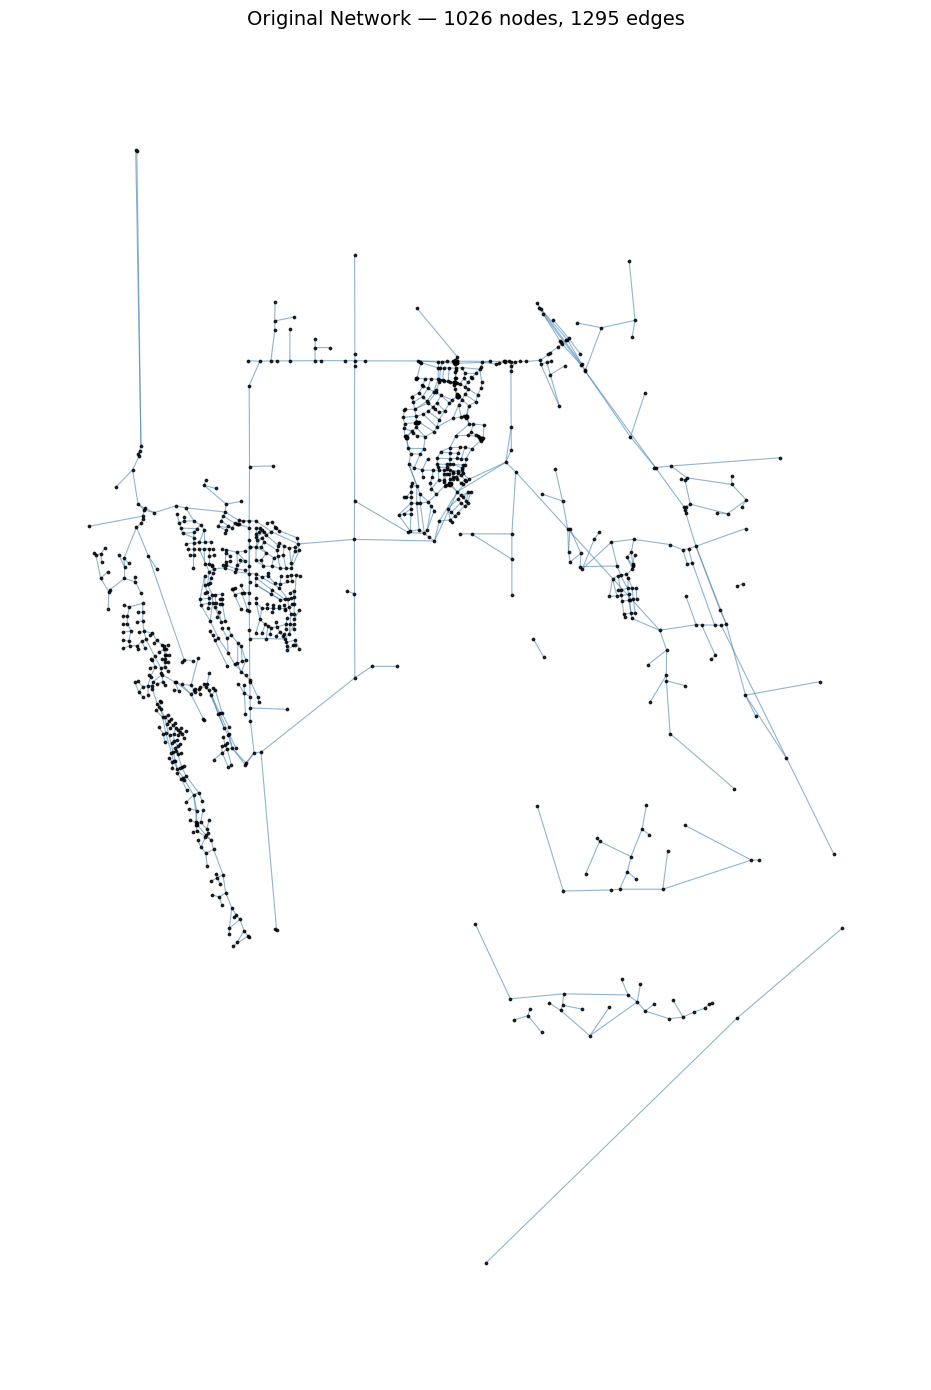

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))
plot_graph(G, title=f"Original Network — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges", ax=ax)
plt.tight_layout()
plt.show()

## 2. Degree Distribution

Understanding the degree distribution tells us how many dead-ends (degree 1) and pass-through roads (degree 2) we have — both are prime candidates for pruning/contraction.

Degree distribution:
  degree 1: 266 nodes (25.9%)
  degree 2: 123 nodes (12.0%)
  degree 3: 500 nodes (48.7%)
  degree 4: 113 nodes (11.0%)
  degree 5: 20 nodes (1.9%)
  degree 6: 2 nodes (0.2%)
  degree 7: 2 nodes (0.2%)


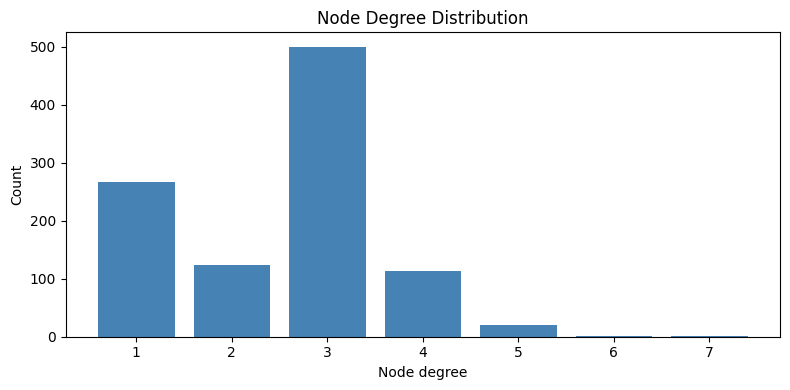

In [6]:
degrees = dict(G.degree())
deg_counts = defaultdict(int)
for d in degrees.values():
    deg_counts[d] += 1

print("Degree distribution:")
for d in sorted(deg_counts.keys()):
    print(f"  degree {d}: {deg_counts[d]} nodes ({100*deg_counts[d]/G.number_of_nodes():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(deg_counts.keys(), deg_counts.values(), color='steelblue')
ax.set_xlabel('Node degree')
ax.set_ylabel('Count')
ax.set_title('Node Degree Distribution')
plt.tight_layout()
plt.show()

## 3. Pruning Method 1: Iterative Leaf Removal

Repeatedly remove all degree-1 nodes (dead-ends). The removed subtrees are cul-de-sacs and branches with no routing choice — perfect for simple DFS rasterization.

In [7]:
def iterative_leaf_pruning(G):
    """Remove all tree-like appendages by iteratively pruning degree-1 nodes.
    
    Returns:
        core: the remaining cyclic core graph
        pruned_edges: list of (u, v) edges that were pruned
        pruned_nodes: set of nodes that were removed
    """
    core = G.copy()
    pruned_edges = []
    pruned_nodes = set()
    
    changed = True
    iteration = 0
    while changed:
        changed = False
        leaves = [n for n in core.nodes() if core.degree(n) == 1]
        if leaves:
            changed = True
            iteration += 1
            for leaf in leaves:
                for neighbor in list(core.neighbors(leaf)):
                    pruned_edges.append((leaf, neighbor))
                pruned_nodes.add(leaf)
                core.remove_node(leaf)
    
    # Also remove isolated nodes (degree 0)
    isolates = list(nx.isolates(core))
    pruned_nodes.update(isolates)
    core.remove_nodes_from(isolates)
    
    print(f"Leaf pruning: {iteration} iterations")
    print(f"  Removed {len(pruned_nodes)} nodes, {len(pruned_edges)} edges")
    print(f"  Core: {core.number_of_nodes()} nodes, {core.number_of_edges()} edges")
    reduction = (1 - core.number_of_edges() / G.number_of_edges()) * 100
    print(f"  Edge reduction: {reduction:.1f}%")
    
    return core, pruned_edges, pruned_nodes

G_core, pruned_edges, pruned_nodes = iterative_leaf_pruning(G)

Leaf pruning: 13 iterations
  Removed 358 nodes, 353 edges
  Core: 668 nodes, 942 edges
  Edge reduction: 27.3%


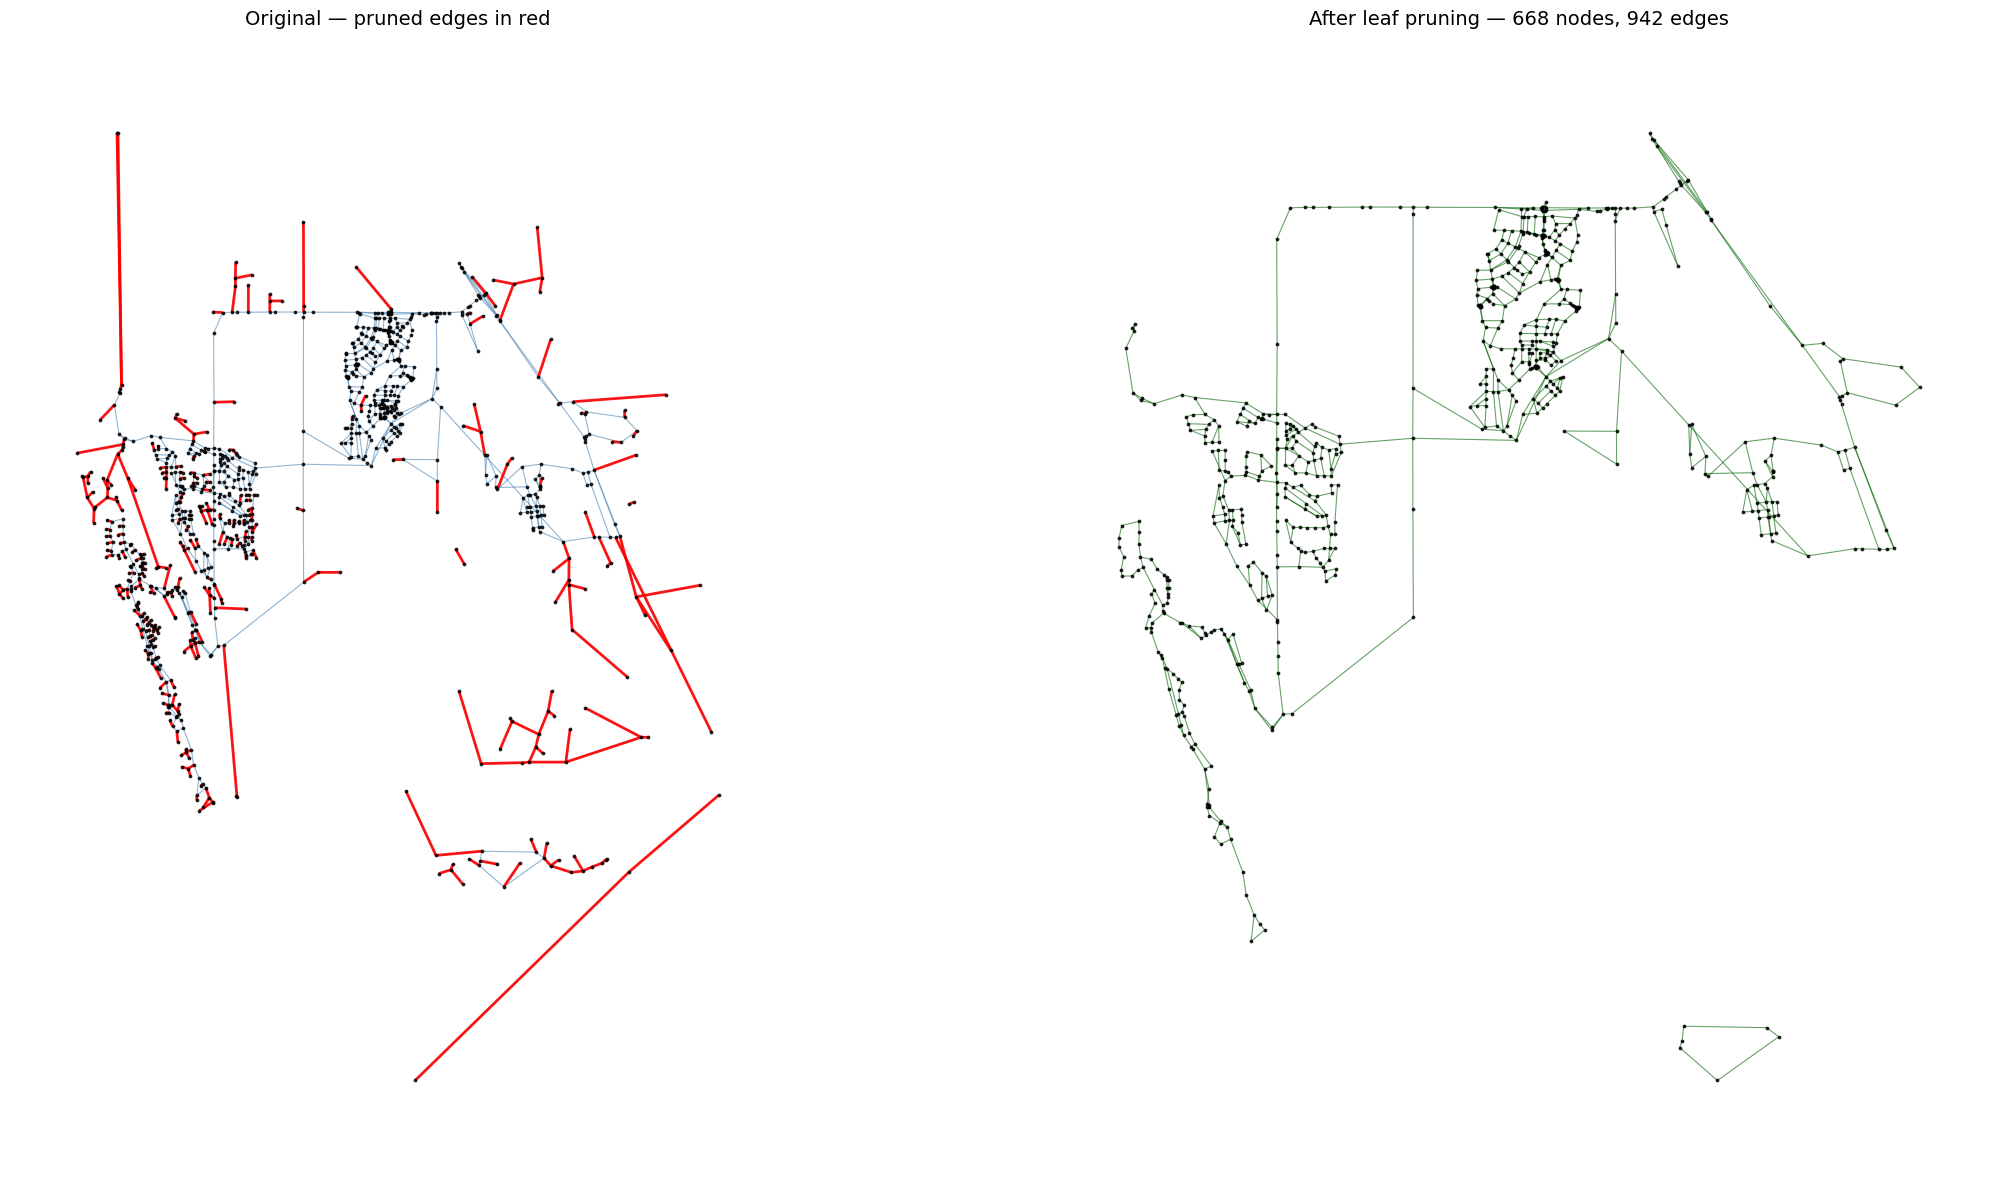

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Original with pruned edges highlighted
plot_graph(G, title="Original — pruned edges in red", ax=axes[0],
           highlight_edges=pruned_edges, highlight_color='red')

# Core after pruning
plot_graph(G_core, title=f"After leaf pruning — {G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges",
           ax=axes[1], edge_color='darkgreen')

plt.tight_layout()
plt.show()

## 4. Pruning Method 2: Degree-2 Chain Contraction

After leaf pruning, contract chains of degree-2 nodes into single weighted edges. These are long roads with no intersections — no routing decision happens along them.

In [ ]:
def contract_degree2_chains(G):
    """Contract chains of degree-2 nodes into single weighted edges.
    
    Returns:
        contracted: new graph with chains replaced by single edges
        chain_map: dict mapping contracted edge (u,v) -> list of original nodes in the chain
    """
    contracted = G.copy()
    chain_map = {}
    
    # Find all degree-2 nodes
    def get_deg2_nodes():
        return [n for n in contracted.nodes() if contracted.degree(n) == 2]
    
    visited = set()
    
    for start in get_deg2_nodes():
        if start in visited or start not in contracted:
            continue
        if contracted.degree(start) != 2:
            continue
        
        # Walk the chain in both directions from start
        chain = [start]
        total_weight = 0.0
        
        neighbors = list(contracted.neighbors(start))
        
        # Walk in direction of neighbors[0]
        prev, curr = start, neighbors[0]
        while curr in contracted and contracted.degree(curr) == 2 and curr not in visited:
            chain.append(curr)
            total_weight += contracted[prev][curr].get('weight', 1.0)
            nbs = [n for n in contracted.neighbors(curr) if n != prev]
            if not nbs:
                break
            prev, curr = curr, nbs[0]
        end1 = curr
        total_weight += contracted[prev][curr].get('weight', 1.0) if contracted.has_edge(prev, curr) else 0
        
        # Walk in direction of neighbors[1]
        prev, curr = start, neighbors[1]
        while curr in contracted and contracted.degree(curr) == 2 and curr not in visited:
            chain.insert(0, curr)
            total_weight += contracted[prev][curr].get('weight', 1.0)
            nbs = [n for n in contracted.neighbors(curr) if n != prev]
            if not nbs:
                break
            prev, curr = curr, nbs[0]
        end0 = curr
        total_weight += contracted[prev][curr].get('weight', 1.0) if contracted.has_edge(prev, curr) else 0
        
        # Mark chain nodes as visited
        visited.update(chain)
        
        # Skip if both ends are the same (small cycle of deg-2 nodes)
        if end0 == end1:
            continue
        
        # Remove chain nodes and add single weighted edge
        for n in chain:
            contracted.remove_node(n)
        
        contracted.add_edge(end0, end1, weight=total_weight, chain_length=len(chain))
        chain_map[(end0, end1)] = chain
    
    print(f"Chain contraction:")
    print(f"  Contracted {len(chain_map)} chains ({sum(len(c) for c in chain_map.values())} internal nodes)")
    print(f"  Result: {contracted.number_of_nodes()} nodes, {contracted.number_of_edges()} edges")
    
    return contracted, chain_map

G_contracted, chain_map = contract_degree2_chains(G_core)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_graph(G_core, title=f"After leaf pruning — {G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges",
           ax=axes[0], edge_color='darkgreen')

plot_graph(G_contracted, title=f"After chain contraction — {G_contracted.number_of_nodes()} nodes, {G_contracted.number_of_edges()} edges",
           ax=axes[1], edge_color='darkorange')

plt.tight_layout()
plt.show()

## 5. Pruning Method 3: Bridge Detection & Biconnected Components

Bridges are edges whose removal disconnects the graph. The **block-cut tree** from biconnected component decomposition gives us a hierarchy:
- **Blocks** (biconnected components) = cyclic subregions with no single point of failure
- **Cut vertices** (articulation points) = where blocks connect

Small peripheral blocks hanging off cut vertices are ideal candidates for rasterization zones.

In [ ]:
# Work on the leaf-pruned core (before chain contraction, since contraction loses topology)
bridges = list(nx.bridges(G_core))
art_points = list(nx.articulation_points(G_core))
bicomps = list(nx.biconnected_components(G_core))

print(f"Bridges: {len(bridges)}")
print(f"Articulation points: {len(art_points)}")
print(f"Biconnected components: {len(bicomps)}")

# Size distribution of biconnected components
bicomp_sizes = sorted([len(bc) for bc in bicomps], reverse=True)
print(f"\nBiconnected component sizes (top 10): {bicomp_sizes[:10]}")
print(f"Components with 1 edge (bridges): {sum(1 for s in bicomp_sizes if s == 2)}")
print(f"Components with >5 nodes: {sum(1 for s in bicomp_sizes if s > 5)}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bicomp_sizes, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Biconnected component size (# nodes)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Biconnected Component Sizes')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize: colour each biconnected component differently,
# highlight bridges in red and articulation points in yellow

fig, ax = plt.subplots(figsize=(14, 14))
pos = get_pos(G_core)

# Sort components largest first so the big one is drawn first
bicomps_sorted = sorted(bicomps, key=len, reverse=True)

# Assign colours
cmap = plt.cm.get_cmap('tab20')
for i, comp in enumerate(bicomps_sorted):
    sub = G_core.subgraph(comp)
    color = cmap(i % 20)
    nx.draw_networkx_edges(sub, pos, ax=ax, edge_color=[color]*sub.number_of_edges(),
                           alpha=0.7, width=1.0)

# Bridges in red
nx.draw_networkx_edges(G_core, pos, edgelist=bridges, ax=ax,
                       edge_color='red', alpha=1.0, width=2.5)

# Articulation points in yellow
art_pos = {n: pos[n] for n in art_points}
nx.draw_networkx_nodes(G_core, pos, nodelist=art_points, ax=ax,
                       node_size=20, node_color='yellow', edgecolors='black', linewidths=0.5)

ax.set_title(f"Biconnected Components (coloured) — Bridges (red) — Articulation Points (yellow)", fontsize=13)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Pruning Method 4: Road Hierarchy Filtering

Use SUMO edge types (highway.trunk, highway.secondary, highway.residential, etc.) to keep only major roads for ACO and rasterize the rest.

In [ ]:
# Count edge types
type_counts = defaultdict(int)
type_lengths = defaultdict(float)
for u, v, data in G.edges(data=True):
    t = data.get('edge_type', 'unknown')
    type_counts[t] += 1
    type_lengths[t] += data.get('weight', 0)

print("Edge types:")
for t in sorted(type_counts.keys()):
    print(f"  {t}: {type_counts[t]} edges, {type_lengths[t]/1000:.1f} km")

In [ ]:
# Filter: keep only roads above residential level
KEEP_TYPES = {
    'highway.trunk', 'highway.trunk_link',
    'highway.secondary', 'highway.secondary_link',
    'highway.tertiary', 'highway.tertiary_link',
}

def filter_by_road_type(G, keep_types):
    edges_to_keep = [(u, v) for u, v, d in G.edges(data=True)
                     if d.get('edge_type', '') in keep_types]
    H = G.edge_subgraph(edges_to_keep).copy()
    # Remove isolated nodes
    isolates = list(nx.isolates(H))
    H.remove_nodes_from(isolates)
    return H

G_major = filter_by_road_type(G, KEEP_TYPES)
print(f"Major roads only: {G_major.number_of_nodes()} nodes, {G_major.number_of_edges()} edges")
print(f"Reduction from original: {(1 - G_major.number_of_edges()/G.number_of_edges())*100:.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Colour original by type
type_colors = {
    'highway.trunk': 'red',
    'highway.trunk_link': 'orangered',
    'highway.secondary': 'orange',
    'highway.secondary_link': 'gold',
    'highway.tertiary': 'green',
    'highway.tertiary_link': 'limegreen',
    'highway.residential': 'lightblue',
    'highway.unclassified': 'gray',
}

pos = get_pos(G)
for etype, color in type_colors.items():
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == etype]
    if edges:
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=axes[0],
                               edge_color=color, alpha=0.7, width=1.2, label=etype.replace('highway.', ''))
axes[0].legend(fontsize=9, loc='upper left')
axes[0].set_title(f"By road type — {G.number_of_edges()} edges", fontsize=13)
axes[0].set_aspect('equal')
axes[0].axis('off')

# Major roads only
plot_graph(G_major, title=f"Major roads only — {G_major.number_of_nodes()} nodes, {G_major.number_of_edges()} edges",
           ax=axes[1], edge_color='darkorange')

plt.tight_layout()
plt.show()

## 7. Combined Pipeline: Leaf Prune → Chain Contract → Small Bicomp Removal

The full recommended reduction pipeline.

In [ ]:
def full_reduction_pipeline(G, min_bicomp_size=5):
    """Full graph reduction: leaf prune → remove small biconnected components → chain contract."""
    print(f"=== ORIGINAL: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges ===")
    print()
    
    # Step 1: Leaf pruning
    print("--- Step 1: Leaf Pruning ---")
    core, _, _ = iterative_leaf_pruning(G)
    print()
    
    # Step 2: Remove small biconnected components (peripheral appendages that happen to have a cycle)
    print(f"--- Step 2: Remove biconnected components with < {min_bicomp_size} nodes ---")
    bicomps = list(nx.biconnected_components(core))
    # Keep the largest component and any component above the threshold
    large_bicomps = [bc for bc in bicomps if len(bc) >= min_bicomp_size]
    keep_nodes = set()
    for bc in large_bicomps:
        keep_nodes.update(bc)
    
    # Also keep articulation points that connect large components
    art_pts = set(nx.articulation_points(core))
    keep_nodes.update(art_pts)
    
    core2 = core.subgraph(keep_nodes).copy()
    # Clean up any new leaves created by removal
    core2, _, _ = iterative_leaf_pruning(core2)
    print(f"  After small bicomp removal: {core2.number_of_nodes()} nodes, {core2.number_of_edges()} edges")
    print()
    
    # Step 3: Chain contraction
    print("--- Step 3: Chain Contraction ---")
    reduced, chains = contract_degree2_chains(core2)
    print()
    
    total_reduction = (1 - reduced.number_of_edges() / G.number_of_edges()) * 100
    print(f"=== FINAL: {reduced.number_of_nodes()} nodes, {reduced.number_of_edges()} edges ===")
    print(f"=== Total edge reduction: {total_reduction:.1f}% ===")
    
    return reduced, chains

G_reduced, chains = full_reduction_pipeline(G, min_bicomp_size=5)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_graph(G, title=f"Original — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges", ax=axes[0])
plot_graph(G_reduced, title=f"Fully Reduced — {G_reduced.number_of_nodes()} nodes, {G_reduced.number_of_edges()} edges",
           ax=axes[1], edge_color='crimson')

plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [ ]:
print(f"{'Stage':<35} {'Nodes':>8} {'Edges':>8} {'Edge %':>8}")
print("-" * 65)
stages = [
    ("Original", G),
    ("After leaf pruning", G_core),
    ("After chain contraction", G_contracted),
    ("Major roads only (type filter)", G_major),
    ("Full pipeline (prune+bicomp+contract)", G_reduced),
]
for name, graph in stages:
    pct = graph.number_of_edges() / G.number_of_edges() * 100
    print(f"{name:<35} {graph.number_of_nodes():>8} {graph.number_of_edges():>8} {pct:>7.1f}%")